In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import pingouin as pg
import scipy.stats as stats
import statsmodels.api as sm
from scipy.stats import zscore
import statsmodels.formula.api as smf
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
import math
import seaborn as sns

### raw data input

In [3]:
dir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Crispr/data/Behavior_test/SauronRaw/20241016_PPI-selected/'
ppi_battery = pd.read_csv(dir+'PPI.csv')
ppi_battery.head()

,ms,solenoid,soft solenoid
0,0,0,0
1,1,0,0
2,2,0,0
3,3,0,0
4,4,0,0


In [6]:
df_ppi_sv = pd.read_csv(dir+'10171.csv')
df_ppi_sv.head()

,name,pack,well,well_index,row,column,well_label,run,submission,physical_plate,...,59990,59991,59992,59993,59994,59995,59996,59997,59998,59999
0,{SDA},NaN,830848,1,1,1,A01,10171,a468527d1122,9107,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,{SDA},NaN,830850,3,1,3,A03,10171,a468527d1122,9107,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,{SDA},NaN,830852,5,1,5,A05,10171,a468527d1122,9107,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,{SDA},NaN,830854,7,1,7,A07,10171,a468527d1122,9107,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,{SDA},NaN,830856,9,1,9,A09,10171,a468527d1122,9107,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### organize stimulus profile

In [8]:
soft_ms = ppi_battery.loc[ppi_battery['soft solenoid']==255, 'ms']
soft_frm = soft_ms.apply(lambda x: x//10)
soft_sec = soft_ms.apply(lambda x: x//1000)
df_soft_tp = pd.concat([soft_ms,soft_frm, soft_sec],axis=1)
df_soft_tp.columns = ['ms', 'frm', 'sec']

strong_ms = ppi_battery.loc[ppi_battery['solenoid']==255, 'ms']
strong_frm = strong_ms.apply(lambda x: x//10)
strong_sec = strong_ms.apply(lambda x: x//1000)
df_strong_tp = pd.concat([strong_ms,strong_frm, strong_sec],axis=1)
df_strong_tp.columns = ['ms', 'frm', 'sec']

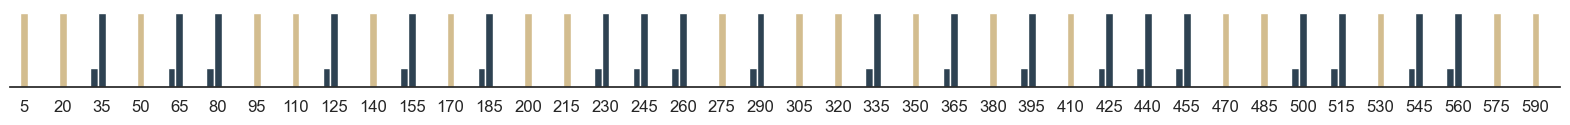

In [9]:
df_tp_profile = pd.concat([pd.Series(df_strong_tp.sec.unique()),
                           pd.Series(df_strong_tp.sec.unique()).apply(lambda x: 'PPI' if x in df_soft_tp.sec.unique() else 'ST')], axis=1)
df_tp_profile.columns = ['tp_sec', 'type']

custom_params = {"axes.spines.right": False, "axes.spines.top": False,"axes.spines.left":False,
                 "xtick.labelsize":12,"ytick.labelsize":10,}
sns.set_theme(style="white", rc=custom_params)

df_plot = df_tp_profile.loc[df_tp_profile.type=='PPI']['tp_sec']-3
df_plot = pd.concat([df_plot, pd.Series(['PPI-WT']*df_plot.shape[0],index = df_plot.index)],axis=1)
df_plot.columns = ['tp_sec', 'type']
df_plot = pd.concat([df_plot,df_tp_profile]).set_index('tp_sec').sort_index()
df_plot['strength'] = df_plot['type'].apply(lambda x: 20 if x in(['ST', 'PPI']) else 5)
df_plot = pd.concat([df_plot,pd.Series(0, index = list(set(np.arange(600)).difference(set(df_plot.index))), name='strength')])
df_plot.fillna('na', inplace=True)
f, ax = plt.subplots(1,1,figsize=(20,1))
g = sns.barplot(x = df_plot.index.astype(int), y=df_plot['strength'], 
                hue = df_plot['type'], palette=['white','#dfc183', '#284358', '#284358'],width=3)
g.set_xticks(np.arange(5, 591,15))
g.set_xticklabels(np.arange(5, 591, 15))
g.set_xlabel('')
g.set_ylabel('')
g.set_yticklabels('')
plt.legend().remove()
plt.show()

### Get the trace of each fish at each strong and soft tap

In [14]:
## find time point (tp) of strong taps preceded by a weak tap
shared_tp = list(set(df_strong_tp.sec.unique()).intersection(set(df_soft_tp.sec.unique())))
shared_tp.sort()
## find time point (tp) of strong taps without a preceded weak tap
strong_only_tps = list(set(df_strong_tp.sec.unique())-set(shared_tp))
strong_only_tps.sort()
strong_only_tps = strong_only_tps[:-1]
df_ppi_fm = df_ppi_sv.copy()
df_ppi_fm = df_ppi_fm.iloc[:, 41:]
df_ppi_fm.columns = df_ppi_fm.columns.astype(int)

df_st_sda = []
df_st_vda = []
for second in df_strong_tp.loc[df_strong_tp.sec.isin(strong_only_tps)].sec.unique()[:-1]:
    start = second*100
    end = start+1500
    df_st_sda.append(df_ppi_fm.iloc[:48, start:end])
    df_st_vda.append(df_ppi_fm.iloc[48:, start:end])
df_st_sda = pd.concat(df_st_sda,axis=1)
df_st_vda = pd.concat(df_st_vda,axis=1)

df_ppiwt_sda = []
df_ppiwt_vda = []
df_ppist_sda = []
df_ppist_vda = []
for second in df_soft_tp.loc[df_soft_tp.sec.isin(shared_tp)].sec.unique():
    start = second*100
    end = start+30
    df_ppiwt_sda.append(df_ppi_fm.iloc[:48, start:end])
    df_ppist_sda.append(df_ppi_fm.iloc[:48, end:(start+1500)])
    df_ppiwt_vda.append(df_ppi_fm.iloc[48:, start:end])
    df_ppist_vda.append(df_ppi_fm.iloc[48:, end:(start+1500)])
df_ppiwt_sda = pd.concat(df_ppiwt_sda,axis=1)
df_ppiwt_vda = pd.concat(df_ppiwt_vda,axis=1)
df_ppist_sda = pd.concat(df_ppist_sda,axis=1)
df_ppist_vda = pd.concat(df_ppist_vda,axis=1)

In [16]:
##output raw dataset for publication
df_comp_st_raw = pd.concat([pd.DataFrame({'mi':df_st_sda.sum(axis=1).to_list(), 'treatment':'SDA'}),
                            pd.DataFrame({'mi':df_st_vda.sum(axis=1).to_list(), 'treatment':'VDA'})])
df_comp_st_raw.index = df_comp_st_raw['treatment']+'-'+df_comp_st_raw.index.astype(str)
df_comp_ppist_raw = pd.concat([pd.DataFrame({'mi':df_ppiwt_sda.sum(axis=1).to_list(), 'treatment':'SDA'}),
                            pd.DataFrame({'mi':df_ppiwt_vda.sum(axis=1).to_list(), 'treatment':'VDA'})])
df_comp_ppist_raw.index = df_comp_ppist_raw['treatment']+'-'+df_comp_ppist_raw.index.astype(str)

df_output = pd.concat([df_comp_st_raw,df_comp_ppist_raw],axis=1).iloc[:,[0,2]]
df_output.columns = ['Pulse-only', 'Prepulse-pulse']
df_output['PPI index'] = df_output['Pulse-only'] - df_output['Prepulse-pulse']
df_output['Genotype'] = df_output.index.str.split('-').str[0]
df_output = df_output[['Genotype','Pulse-only', 'Prepulse-pulse', 'PPI index']]

output_dir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/submission_2025/Supplementary_tables/'
fn='Table S8 Behavior data of PPI assay.xlsx'
with pd.ExcelWriter(
        output_dir+fn,
        mode="a",
        engine="openpyxl",
        if_sheet_exists="replace",
    ) as writer:
    df_output.to_excel(writer, sheet_name="Cummulative_MI", index=False)
    
df_output

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/submission_2025/Supplementary_tables/Table S8 Behavior data of PPI assay.xlsx'

In [18]:
## clean up raw dataset using IQR based outlier removal
def IQR_outlier(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3+1.5*IQR
    lower = Q1-1.5*IQR
    return df.loc[(df[column]>lower)&(df[column]<upper)]

df_comp_st = pd.concat([
    IQR_outlier(pd.DataFrame({'mi':df_st_sda.sum(axis=1).to_list(), 'treatment':'SDA'}), 'mi'), 
    IQR_outlier(pd.DataFrame({'mi':df_st_vda.sum(axis=1).to_list(), 'treatment':'VDA'}), 'mi')])
df_comp_st['param']='ST'

df_comp_ppiwt = pd.concat([
    IQR_outlier(pd.DataFrame({'mi':df_ppiwt_sda.sum(axis=1).to_list(), 'treatment':'SDA'}), 'mi'), 
    IQR_outlier(pd.DataFrame({'mi':df_ppiwt_vda.sum(axis=1).to_list(), 'treatment':'VDA'}), 'mi')])
df_comp_ppiwt['param']='PPIwt'

df_comp_ppist = pd.concat([
    IQR_outlier(pd.DataFrame({'mi':df_ppist_sda.sum(axis=1).to_list(), 'treatment':'SDA'}), 'mi'), 
    IQR_outlier(pd.DataFrame({'mi':df_ppist_vda.sum(axis=1).to_list(), 'treatment':'VDA'}), 'mi')])
df_comp_ppist['param']='PPIst'

df_comp_hab = pd.concat([
    IQR_outlier(pd.DataFrame({'mi':(df_st_sda.sum(axis=1)-df_ppist_sda.sum(axis=1)).to_list(), 'treatment':'SDA'}), 'mi'), 
    IQR_outlier(pd.DataFrame({'mi':(df_st_vda.sum(axis=1)-df_ppist_vda.sum(axis=1)).to_list(), 'treatment':'VDA'}), 'mi')])
df_comp_hab['param']='hab'

### Statistical comparison

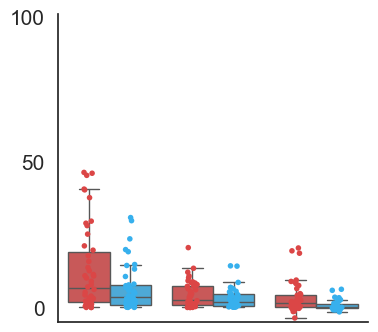

In [23]:
##visualize data
df_comp = pd.concat([df_comp_st,df_comp_ppist,df_comp_hab],axis=0)
df_plot = df_comp.copy()

custom_params = {"axes.spines.right": False, "axes.spines.top": False,
                 "xtick.labelsize":8,"ytick.labelsize":8}
sns.set_style("white",rc=custom_params)
f, ax = plt.subplots(1,1, figsize=(4,4))
g = sns.boxplot(
    data=df_plot, 
    x='param', 
    y='mi', 
    hue='treatment',
    ax=ax,
    palette=['#db4646','#37B0ED'],
    fill = True,
    showfliers=False
)

g = sns.stripplot(
    data=df_plot, 
    x='param', 
    y='mi', 
    hue='treatment',
    palette=['#db4646','#37B0ED'],
    size=4,
    ax=ax,
    dodge=True
)

magnitude= 10**round(math.log(df_plot['mi'].max(),10))
ymax= magnitude*(df_plot['mi'].max()//magnitude+1)
if ymax//magnitude<3:
    stepsize = magnitude/2
else:
    stepsize = magnitude
g.set_xlabel('')
g.set_ylabel('')
g.set_ylim((stepsize/10)*(-1), ymax*1.01)
g.set_yticks(np.arange(0,ymax*1.01,stepsize))

if magnitude>=1e4:
    g.set_yticklabels((np.arange(0,ymax*1.01,stepsize)/1e3).astype(int), fontsize=15)
else:
    g.set_yticklabels(np.arange(0,ymax*1.01,stepsize).astype(int), fontsize=15)
g.set_xticklabels('')
plt.legend().remove()
plt.show()

In [25]:
###compare strong only tap and PPI strong tap within SDA and VDA
temp_fish = df_comp.loc[(df_comp.treatment=='SDA')&(df_comp.param=='PPIst')].index.intersection(df_comp.loc[(df_comp.treatment=='SDA')&(df_comp.param=='ST')].index)
sda_ppi_vs_st = pg.ttest(df_comp.loc[(df_comp.treatment=='SDA')&(df_comp.param=='PPIst')].loc[temp_fish, 'mi'], 
         df_comp.loc[(df_comp.treatment=='SDA')&(df_comp.param=='ST')].loc[temp_fish, 'mi'],
         paired=True)

df_temp_sda = pd.concat([df_comp.loc[(df_comp.treatment=='SDA')&(df_comp.param=='PPIst')].loc[temp_fish, 'mi'], 
         df_comp.loc[(df_comp.treatment=='SDA')&(df_comp.param=='ST')].loc[temp_fish, 'mi']], axis=1)
df_temp_sda.columns=['PPIst', 'ST']
df_temp_sda['treatment']='sda'

temp_fish = df_comp.loc[(df_comp.treatment=='VDA')&(df_comp.param=='PPIst')].index.intersection(df_comp.loc[(df_comp.treatment=='VDA')&(df_comp.param=='ST')].index)
vda_ppi_vs_st = pg.ttest(df_comp.loc[(df_comp.treatment=='VDA')&(df_comp.param=='PPIst')].loc[temp_fish, 'mi'], 
         df_comp.loc[(df_comp.treatment=='VDA')&(df_comp.param=='ST')].loc[temp_fish, 'mi'],
         paired=True)
df_temp_vda = pd.concat([df_comp.loc[(df_comp.treatment=='VDA')&(df_comp.param=='PPIst')].loc[temp_fish, 'mi'], 
         df_comp.loc[(df_comp.treatment=='VDA')&(df_comp.param=='ST')].loc[temp_fish, 'mi']], axis=1)
df_temp_vda.columns=['PPIst', 'ST']
df_temp_vda['treatment'] = 'vda'
###compare strong only tap and PPI strong tap between SDA and VDA
df_temp = pd.concat([df_temp_sda, df_temp_vda])
st_vda_vs_sda = pg.ttest(df_temp.loc[df_temp.treatment=='sda'].ST, df_temp.loc[df_temp.treatment=='vda'].ST)
ppi_vda_vs_sda = pg.ancova(data=df_temp, dv='PPIst', covar='ST', between='treatment')

###print the pvalue for the four comparisons
[sda_ppi_vs_st['p-val'].iloc[0],vda_ppi_vs_st['p-val'].iloc[0], st_vda_vs_sda['p-val'].iloc[0],ppi_vda_vs_sda['p-unc'].iloc[0]]

[0.0002712736714593243,
 0.020689660169779446,
 0.006079562955554704,
 0.57381605969524]

### Comparison of peak MI

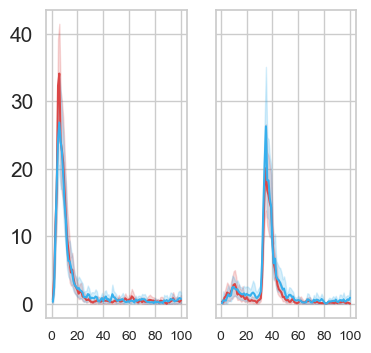

In [28]:
##visualize the trace for publication
df_st_avg_sda = []
for second in df_strong_tp.loc[df_strong_tp.sec.isin(strong_only_tps)].sec.unique()[:-1]:
    start = second*100
    end = start+1499
    df_temp = df_st_sda.loc[:,start:end]
    df_temp.columns = np.arange(1,1501)
    df_st_avg_sda.append(df_temp)
df_st_avg_sda = pd.concat(df_st_avg_sda,axis=1).transpose().reset_index().groupby('index').mean().transpose()

df_st_avg_vda = []
for second in df_strong_tp.loc[df_strong_tp.sec.isin(strong_only_tps)].sec.unique()[:-1]:
    start = second*100
    end = start+1499
    frames = df_strong_tp.loc[df_strong_tp['sec']==second].frm.unique()
    df_temp = df_st_vda.loc[:,start:end]
    df_temp.columns = np.arange(1,1501)
    df_st_avg_vda.append(df_temp)
df_st_avg_vda = pd.concat(df_st_avg_vda,axis=1).transpose().reset_index().groupby('index').mean().transpose()

custom_params = {"axes.spines.right": True, "axes.spines.top": True,
                 "xtick.labelsize":15,"ytick.labelsize":15,}
sns.set_theme(style="whitegrid", rc=custom_params)

f, ax = plt.subplots(1,2, figsize=(4,4),sharey=True)

df_temp1 = df_st_avg_sda.iloc[:, :100].melt()
df_temp1.columns = ['tp', 'mi']
df_temp1['treatment']='sda'

df_temp2 = df_st_avg_vda.iloc[:, :100].melt()
df_temp2.columns = ['tp', 'mi']
df_temp2['treatment']='vda'

df_plot = pd.concat([df_temp1, df_temp2])
g=sns.lineplot(df_plot,x="tp", y="mi",errorbar=('ci', 95), hue='treatment',palette=['#db4646','#37B0ED'],ax=ax[0])
g.set_xlabel('')
g.set_ylabel('')
g.set_xticks(np.arange(0, 100+1, 20))
g.set_xticklabels(np.arange(0, 100+1, 20).astype(int), fontsize=10)
ax[0].legend().remove()

df_ppi_avg_sda = []
df_ppi_sda = pd.concat([df_ppist_sda, df_ppiwt_sda],axis=1)
df_ppi_sda = df_ppi_sda.loc[:,df_ppi_sda.columns.sort_values()]
for second in df_strong_tp.loc[df_strong_tp.sec.isin(shared_tp)].sec.unique():
    start = second*100
    end = second*100+1499
    df_temp = df_ppi_sda.loc[:,start:end]
    df_temp.columns = np.arange(1,1501)
    df_ppi_avg_sda.append(df_temp)
df_ppi_avg_sda = pd.concat(df_ppi_avg_sda,axis=1).transpose().reset_index().groupby('index').mean().transpose()

df_ppi_avg_vda = []
df_ppi_vda = pd.concat([df_ppist_vda, df_ppiwt_vda],axis=1)
df_ppi_vda = df_ppi_vda.loc[:,df_ppi_vda.columns.sort_values()]
for second in df_strong_tp.loc[df_strong_tp.sec.isin(shared_tp)].sec.unique():
    start = second*100
    end = second*100+1499
    df_temp = df_ppi_vda.loc[:,start:end]
    df_temp.columns = np.arange(1,1501)
    df_ppi_avg_vda.append(df_temp)
df_ppi_avg_vda = pd.concat(df_ppi_avg_vda,axis=1).transpose().reset_index().groupby('index').mean().transpose()

#custom_params = {"axes.spines.right": True, "axes.spines.top": True,
                 #"xtick.labelsize":15,"ytick.labelsize":15,}
#sns.set_theme(style="whitegrid", rc=custom_params)

#f, ax = plt.subplots(1,1, figsize=(4,4),sharey=True)

df_temp1 = df_ppi_avg_sda.iloc[:,:100].melt()
df_temp1.columns = ['tp', 'mi']
df_temp1['treatment']='sda'

df_temp2 = df_ppi_avg_vda.iloc[:,:100].melt()
df_temp2.columns = ['tp', 'mi']
df_temp2['treatment']='vda'

df_plot = pd.concat([df_temp1, df_temp2])
g=sns.lineplot(df_plot,x="tp", y="mi",errorbar=('ci', 95), hue='treatment',palette=['#db4646','#37B0ED'],ax=ax[1])
g.set_xlabel('')
g.set_ylabel('')
ax[1].legend().remove()
g.set_xticks(np.arange(0, 100+1, 20))
g.set_xticklabels(np.arange(0, 100+1, 20).astype(int), fontsize=10)
plt.show()


### Comparison of peak MI bewtween SDA and VDA

In [31]:
df_temp1 = pd.concat([df_ppi_avg_sda.max(axis=1), df_st_avg_sda.max(axis=1)],axis=1)
df_temp1.columns=['ppist', 'st']
df_temp1['treatment']='SDA'
df_temp2 = pd.concat([df_ppi_avg_vda.max(axis=1), df_st_avg_vda.max(axis=1)],axis=1)
df_temp2.columns=['ppist', 'st']
df_temp2['treatment']='VDA'
df_temp = pd.concat([df_temp1,df_temp2],axis=0)
df_temp['hab_index'] = df_temp['st']-df_temp['ppist']
df_temp

,ppist,st,treatment,hab_index
0,0.45,0.111111,SDA,-0.338889
1,19.45,27.166667,SDA,7.716667
2,24.80,31.388889,SDA,6.588889
3,14.80,44.388889,SDA,29.588889
4,13.95,17.444444,SDA,3.494444
...,...,...,...,...
91,70.45,56.888889,VDA,-13.561111
92,29.15,36.611111,VDA,7.461111
93,14.65,17.055556,VDA,2.405556
94,11.10,22.666667,VDA,11.566667


In [134]:
##output raw dataset for publication
df_output = df_temp.copy()
df_output.columns = ['Prepulse-pulse', 'Pulse-only', 'Genotype','PPI index']
df_output = df_output[['Genotype','Pulse-only','Prepulse-pulse','PPI index']]

output_dir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/submission_2025/Supplementary_tables/'
fn='Table S8 Behavior data of PPI assay.xlsx'
with pd.ExcelWriter(
        output_dir+fn,
        mode="a",
        engine="openpyxl",
        if_sheet_exists="replace",
    ) as writer:
    df_output.to_excel(writer, sheet_name="Peak_MI", index=False)
    
df_output

,Genotype,Pulse-only,Prepulse-pulse,PPI index
0,SDA,0.111111,0.45,-0.338889
1,SDA,27.166667,19.45,7.716667
2,SDA,31.388889,24.80,6.588889
3,SDA,44.388889,14.80,29.588889
4,SDA,17.444444,13.95,3.494444
...,...,...,...,...
91,VDA,56.888889,70.45,-13.561111
92,VDA,36.611111,29.15,7.461111
93,VDA,17.055556,14.65,2.405556
94,VDA,22.666667,11.10,11.566667


In [33]:
## comparison of prepulse-pulse tap
pg.anova(data=df_temp, dv='ppist',between='treatment')

,Source,ddof1,ddof2,F,p-unc,np2
0,treatment,1,94,0.296731,0.587229,0.003147


In [35]:
## comparison of pulse-alone tap
pg.anova(data=df_temp, dv='st',between='treatment')

,Source,ddof1,ddof2,F,p-unc,np2
0,treatment,1,94,0.904594,0.343992,0.009532


In [37]:
## comparison of PPI index
pg.anova(data=df_temp, dv='hab_index',between='treatment')

,Source,ddof1,ddof2,F,p-unc,np2
0,treatment,1,94,7.069417,0.009217,0.069946


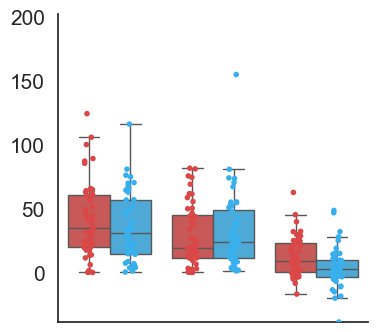

In [39]:
## visualize the comparisons
df_plot = df_temp.copy()

df_temp1 = df_plot.loc[:,['treatment', 'st']].rename(columns={'st':'peak_mi'})
df_temp1['param'] = 'st'

df_temp2 = df_plot.loc[:,['treatment', 'ppist']].rename(columns={'ppist':'peak_mi'})
df_temp2['param'] = 'ppist'

df_temp3 = df_plot.loc[:,['treatment', 'hab_index']].rename(columns={'hab_index':'peak_mi'})
df_temp3['param'] = 'hab_index'

df_plot = pd.concat([df_temp1, df_temp2, df_temp3])
custom_params = {"axes.spines.right": False, "axes.spines.top": False,
                 "xtick.labelsize":8,"ytick.labelsize":8}
sns.set_style("white",rc=custom_params)
f, ax = plt.subplots(1,1, figsize=(4,4))
g = sns.boxplot(
    data=df_plot, 
    x='param', 
    y='peak_mi', 
    hue='treatment',
    ax=ax,
    palette=['#db4646','#37B0ED'],
    fill = True,
    showfliers=False
)

g = sns.stripplot(
    data=df_plot, 
    x='param', 
    y='peak_mi', 
    hue='treatment',
    palette=['#db4646','#37B0ED'],
    size=4,
    ax=ax,
    dodge=True
)

magnitude= 10**round(math.log(df_plot['peak_mi'].max(),10))
ymax= magnitude*(df_plot['peak_mi'].max()//magnitude+1)
if ymax//magnitude<3:
    stepsize = magnitude/2
else:
    stepsize = magnitude
g.set_xlabel('')
g.set_ylabel('')
ymin = min(df_plot['peak_mi'].min(),(stepsize/10)*(-1))
g.set_ylim(ymin, ymax*1.01)
g.set_yticks(np.arange(0,ymax*1.01,stepsize))

if magnitude>=1e4:
    g.set_yticklabels((np.arange(0,ymax*1.01,stepsize)/1e3).astype(int), fontsize=15)
else:
    g.set_yticklabels(np.arange(0,ymax*1.01,stepsize).astype(int), fontsize=15)
g.set_xticklabels('')
plt.legend().remove()
plt.show()